# Trading Game #1 — Multivariate Pair Trading (G21 — Orange Juice)
**Reference:** Yang & Malik (2024), *Optimal Market-Neutral Multivariate Pair Trading*  
**Strategy:** Build a beta-neutral, dollar-neutral basket of OJ-correlated equities 
optimised via Gurobi QP, then trade spread mean-reversion with 10 bps transaction costs.

**Pipeline:**  
`Data` → `Cointegration screening (EDA)` → `Formation/Trading split` → 
`Gurobi optimisation` → `Spread / Z-score` → `Backtest` → `Metrics & plots`

In [25]:
# DATASET UPLOAD  (Google Colab)
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import files
    print('Upload dataset_G21.csv when the file picker appears...')
    uploaded = files.upload()
    DATA_PATH = 'dataset_G21.csv'
    # Install Gurobi on Colab
    os.system('pip install gurobipy -q')
else:
    # Local execution
    current_dir   = os.getcwd()
    project_root  = os.path.abspath(os.path.join(current_dir, '..'))
    DATA_PATH     = os.path.join(project_root, 'data', 'dataset_G21.csv')

print(f'DATA_PATH = {DATA_PATH}')

DATA_PATH = c:\Users\reyne\Desktop\Git Repositories\Trading-Game-Commodities\data\dataset_G21.csv


In [26]:
import itertools, warnings
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot       as plt
import matplotlib.gridspec     as gridspec
import seaborn                 as sns
import gurobipy as gp
from gurobipy import GRB

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')

# Parameters
ANCHOR_TICKER   = 'OJ=F'
SELECTED_ASSETS = ['MOO', 'CC=F', 'KO', 'MNST', 'DBA'] # Selected by p-value (see eda.ipynb)

FORMATION_RATIO = 0.70  # 70 % in-sample and 30 % out-of-sample
TC              = 0.001 # 10 bps per leg
RISK_FREE_RATE  = 0.04  # 4 % p.a. (used the US 10y treasury)

print('Imports OK. Parameters set.')

Imports OK. Parameters set.


In [27]:
# Load CSV (multi-level header produced by yfinance)
df_raw = pd.read_csv(DATA_PATH, header=[0, 1], index_col=0)
if df_raw.index[0] == 'Date':
    df_raw = df_raw.drop(index='Date')
df_raw.index = pd.to_datetime(df_raw.index)

df_prices = df_raw['Close'].astype(float).copy()
df_prices = df_prices[[ANCHOR_TICKER] + SELECTED_ASSETS].dropna()


# Formation / Trading split
cutoff       = int(len(df_prices) * FORMATION_RATIO)
df_formation = df_prices.iloc[:cutoff].copy()
df_trading   = df_prices.iloc[cutoff:].copy()


print(f'Total observations : {len(df_prices)}')
print(f'Formation period   : {df_formation.index[0].date()} → '
      f'{df_formation.index[-1].date()}  ({len(df_formation)} days)')
print(f'Trading period     : {df_trading.index[0].date()} → '
      f'{df_trading.index[-1].date()}  ({len(df_trading)} days)')
display(df_prices.head(3))

Total observations : 2010
Formation period   : 2018-01-02 → 2023-08-04  (1407 days)
Trading period     : 2023-08-07 → 2025-12-30  (603 days)


Ticker,OJ=F,MOO,CC=F,KO,MNST,DBA
Date,,,,,,
2018-01-02,135.699997,62.240002,1936.0,45.540001,31.355000,18.969999
2018-01-03,139.500000,62.689999,1907.0,45.439999,31.559999,18.959999
2018-01-04,139.500000,63.200001,1905.0,46.080002,31.680000,18.930000


## 1. Asset Selection - Cointegration Screening
Engle-Granger cointegration tests were performed in `eda.ipynb` against `OJ=F` 
over rolling windows of 4, 5 and 6 years (2018-2025).  

The **5 equities with the lowest p-values** from the G21 universe were retained: 
**MOO, KO, CC=F, MNST, and DBA**.  

These consumer-staples and beverage companies share input-cost exposure with 
orange juice (sugar, water, logistics), justifying a long-run co-movement hypothesis.

However, the results were quite disappointing (see eda.ipynb) It was pretty tough to find tickers with a reasonable chance of being cointegrated with Orange Juice (by p-value). I actually had to work with tickers that may not be cointegrated with Orange Juice in order to try the strategy.

In [28]:
def compute_betas_and_cov(
        df: pd.DataFrame, anchor: str, assets: list
) -> tuple:
    """
    Compute market-betas of each equity relative to the anchor,
    and the return covariance matrix Σ.
    Both are estimated on FORMATION data only (no look-ahead).

    Beta_i = Cov(R_i, R_anchor) / Var(R_anchor)
    """
    log_ret  = np.log(df / df.shift(1)).dropna()
    full_cov = log_ret[[anchor] + assets].cov()
    var_a    = log_ret[anchor].var()
    betas    = full_cov.loc[assets, anchor] / var_a
    cov_mat  = log_ret[assets].cov()
    return betas, cov_mat


betas, cov_matrix = compute_betas_and_cov(
    df_formation, ANCHOR_TICKER, SELECTED_ASSETS
)

print('Market betas (βᵢ = Cov(Rᵢ, R_OJ) / Var(R_OJ)):')
for a, b in betas.items():
    print(f'  {a:6s}: {b:+.4f}')

Market betas (βᵢ = Cov(Rᵢ, R_OJ) / Var(R_OJ)):
  MOO   : +0.0571
  CC=F  : -0.0301
  KO    : +0.0331
  MNST  : +0.0433
  DBA   : +0.0551


In [29]:
def optimize_basket_weights(
        cov_matrix: pd.DataFrame,
        betas: pd.Series
) -> pd.Series:
    """
    Gurobi QP — minimise portfolio variance subject to:
      1. Beta-neutrality  : Σ βᵢ wᵢ = 0      (Pβ = 0)
      2. Dollar-neutrality: Σ wᵢ    = 0      (equal long/short exposure)
      3. Capital deployed : Σ|wᵢ|   = 1      (fully invested)
      4. SOS1 per asset   : each stock is EITHER long OR short, not both

    Weights are split into long part wp ≥ 0 and short part wm ≥ 0
    with net signed weight  w = wp - wm.
    """
    assets   = list(cov_matrix.columns)
    n        = len(assets)
    Sigma    = cov_matrix.to_numpy()
    beta_vec = betas.to_numpy()

    env = gp.Env(empty=True)
    env.setParam('OutputFlag', 0)
    env.start()
    model = gp.Model('multivariate_pairs_trading', env=env)

    wp = model.addMVar(n, lb=0.0, ub=1.0, name='wp') # long allocations
    wm = model.addMVar(n, lb=0.0, ub=1.0, name='wm') # short allocations

    # Objective : minimise (wp-wm)ᵀ Σ (wp-wm)
    obj = (wp @ Sigma @ wp
           - 2.0 * (wp @ (Sigma @ wm))
           + wm @ Sigma @ wm)
    model.setObjective(obj, GRB.MINIMIZE)

    # Beta neutrality
    model.addConstr(beta_vec @ wp - beta_vec @ wm == 0, name='beta_neutral')

    # Dollar neutrality : sum(long) = sum(short)
    model.addConstr(wp.sum() == wm.sum(), name='dollar_neutral')

    # Total capital = 1
    model.addConstr(wp.sum() + wm.sum() == 1, name='total_capital')

    # SOS1 : each asset is either long OR short (prevents degenerate w=0 solution)
    for i in range(n):
        model.addSOS(GRB.SOS_TYPE1, [wp[i], wm[i]])

    model.optimize()

    if model.status == GRB.OPTIMAL:
        w_net = pd.Series(wp.X - wm.X, index=assets, name='Weight')
        return w_net
    raise RuntimeError(f'Gurobi status {model.status}')


optimized_weights = optimize_basket_weights(cov_matrix, betas)

print('Optimised basket weights:')
for a, w in optimized_weights.items():
    side = 'LONG ' if w > 0 else 'SHORT'
    print(f'  {a:6s}: {side}  {w:+.4f}')
print(f'\nConstraint checks:')
print(f'  Σ βᵢwᵢ = {(betas * optimized_weights).sum():.2e}   (≈ 0 ✓ beta-neutral)')
print(f'  Σ wᵢ   = {optimized_weights.sum():.2e}             (≈ 0 ✓ dollar-neutral)')
print(f'  Σ|wᵢ|  = {optimized_weights.abs().sum():.4f}              (= 1 ✓ fully invested)')

Optimised basket weights:
  MOO   : SHORT  -0.4291
  CC=F  : SHORT  -0.0709
  KO    : LONG   +0.1799
  MNST  : LONG   +0.1037
  DBA   : LONG   +0.2163

Constraint checks:
  Σ βᵢwᵢ = -1.73e-18   (≈ 0 ✓ beta-neutral)
  Σ wᵢ   = 0.00e+00             (≈ 0 ✓ dollar-neutral)
  Σ|wᵢ|  = 1.0000              (= 1 ✓ fully invested)


In [30]:
def compute_spread_and_zscore(
        df: pd.DataFrame, anchor: str, assets: list,
        weights: pd.Series, window: int = 60
) -> pd.DataFrame:
    """
    Spread  = log(P_anchor) - Σ wᵢ log(Pᵢ)
    Z-score = rolling standardisation  (window days)
    """
    log_p      = np.log(df)
    basket     = (log_p[assets] * weights).sum(axis=1)
    spread     = log_p[anchor] - basket

    roll_mean  = spread.rolling(window).mean()
    roll_std   = spread.rolling(window).std()
    z_score    = (spread - roll_mean) / roll_std

    return pd.DataFrame({'Spread': spread, 'Z_Score': z_score}).dropna()


# Weights estimated on FORMATION -> spread computed on TRADING (out-of-sample)
# Window parameter will be tuned by grid search below
DEFAULT_WINDOW = 60
df_signals = compute_spread_and_zscore(
    df_trading, ANCHOR_TICKER, SELECTED_ASSETS,
    optimized_weights, window=DEFAULT_WINDOW
)
print(f'Signal series: {len(df_signals)} observations')
print(df_signals['Z_Score'].describe().round(3).to_string())

Signal series: 544 observations
count    544.000
mean      -0.137
std        1.403
min       -3.925
25%       -1.136
50%       -0.013
75%        0.763
max        3.468


In [31]:
def run_backtest(
        df_sig: pd.DataFrame,
        open_threshold:  float = 1.5,
        close_threshold: float = 0.5,
        tc: float = 0.001
) -> pd.DataFrame:
    """
    State-machine backtest — signal at t-1 → execution at t (no look-ahead).

    +1 = long spread  (anchor undervalued)
    -1 = short spread (anchor overvalued)
     0 = flat

    10 bps applied on every position change (open + close).
    """
    df  = df_sig.copy()
    n   = len(df)
    z   = df['Z_Score'].to_numpy()
    pos = np.zeros(n)
    cur = 0

    for t in range(1, n):
        pz = z[t - 1] # previous z-score -> no look-ahead
        if cur == 0:
            if   pz >  open_threshold: cur = -1
            elif pz < -open_threshold: cur =  1
        elif cur == -1:
            if pz <  close_threshold: cur = 0
        elif cur ==  1:
            if pz > -close_threshold: cur = 0
        pos[t] = cur

    df['Position']      = pos
    df['Spread_Return'] = df['Spread'].diff()
    df['Gross_Return']  = df['Position'].shift(1) * df['Spread_Return']
    df['TC']            = df['Position'].diff().abs() * tc
    df['Net_Return']    = df['Gross_Return'] - df['TC'].fillna(0)
    df['Cum_Return']    = df['Net_Return'].cumsum()
    return df


df_bt = run_backtest(
    df_signals,
    open_threshold  = OPEN_THRESHOLD  if 'OPEN_THRESHOLD'  in dir() else 1.5,
    close_threshold = CLOSE_THRESHOLD if 'CLOSE_THRESHOLD' in dir() else 0.5,
    tc = TC
)
trade_count = int((df_bt['Position'].diff().abs() > 0).sum() // 2)
print(f'Backtest complete. Round-trips: {trade_count}')

Backtest complete. Round-trips: 13


In [ ]:
def calculate_metrics(
        returns: pd.Series,
        rf: float = 0.04,
        T: int    = 252
) -> dict:
    """Annualised Sharpe, Max Drawdown, Calmar Ratio."""
    ann_ret = returns.mean() * T
    ann_vol = returns.std()  * np.sqrt(T)
    sharpe  = (ann_ret - rf) / ann_vol if ann_vol else 0.0
    cum     = (1 + returns).cumprod()
    dd      = (cum.cummax() - cum) / cum.cummax()
    mdd     = dd.max()
    calmar  = ann_ret / mdd if mdd else 0.0
    return {'Annualized_Return': ann_ret, 'Annualized_Volatility': ann_vol,
            'Sharpe_Ratio': sharpe, 'Max_Drawdown': mdd, 'Calmar_Ratio': calmar}


FMT = {'Annualized_Return':'{:.2%}','Annualized_Volatility':'{:.2%}',
       'Sharpe_Ratio':'{:.2f}', 'Max_Drawdown':'{:.2%}','Calmar_Ratio':'{:.2f}'}

bh_returns    = df_trading[ANCHOR_TICKER].pct_change().dropna()
strat_metrics = calculate_metrics(df_bt['Net_Return'].dropna(), RISK_FREE_RATE)
bench_metrics = calculate_metrics(bh_returns, RISK_FREE_RATE)

print('── Performance Table (default parameters) ──')
results = pd.DataFrame(
    {'OTT Strategy (Gurobi)': strat_metrics, 'Buy & Hold OJ=F': bench_metrics}
).T
display(results.style.format(FMT))

── Performance Table (default parameters) ──


,Annualized_Return,Annualized_Volatility,Sharpe_Ratio,Max_Drawdown,Calmar_Ratio
OTT Strategy (Gurobi),-0.08%,40.17%,-0.10,60.51%,-0.00
Buy & Hold OJ=F,-3.75%,52.11%,-0.15,75.36%,-0.05


In [33]:
def grid_search_hyperparameters(
        df_form, df_trade, anchor, assets, weights, tc=0.001
) -> tuple:
    """
    Tune (window, open_threshold, close_threshold) on FORMATION spread,
    then evaluate the best config on TRADING spread (out-of-sample).
    """
    windows          = [30, 45, 60, 90]
    open_thresholds  = [1.0, 1.5, 2.0, 2.5]
    close_thresholds = [0.0, 0.5, 1.0]

    best_sharpe, best_params, best_df = -np.inf, {}, None

    for w, o, c in itertools.product(windows, open_thresholds, close_thresholds):
        if o <= c:
            continue
        # Validate on formation data
        sig_f  = compute_spread_and_zscore(df_form,  anchor, assets, weights, w)
        bt_f   = run_backtest(sig_f, o, c, tc)
        sharpe = calculate_metrics(bt_f['Net_Return'].dropna())['Sharpe_Ratio']

        if sharpe > best_sharpe:
            best_sharpe = sharpe
            best_params = {'window': w, 'open_threshold': o, 'close_threshold': c}
            # Apply to trading data
            sig_t  = compute_spread_and_zscore(df_trade, anchor, assets, weights, w)
            best_df = run_backtest(sig_t, o, c, tc)

    return best_params, best_df


print('Grid search running (formation → trading evaluation)...')
best_params, df_bt_opt = grid_search_hyperparameters(
    df_formation, df_trading,
    ANCHOR_TICKER, SELECTED_ASSETS, optimized_weights, tc=TC
)

OPT_W  = best_params['window']
OPT_O  = best_params['open_threshold']
OPT_C  = best_params['close_threshold']
df_signals_opt = compute_spread_and_zscore(
    df_trading, ANCHOR_TICKER, SELECTED_ASSETS, optimized_weights, window=OPT_W
)

print(f'\nOptimal hyperparameters:')
print(f'  Rolling window  : {OPT_W} days')
print(f'  Open threshold  : {OPT_O} σ')
print(f'  Close threshold : {OPT_C} σ')

strat_opt = calculate_metrics(df_bt_opt['Net_Return'].dropna(), RISK_FREE_RATE)
print('\n── Performance Table (optimised parameters) ──')
results_opt = pd.DataFrame(
    {'OTT Strategy (optimised)': strat_opt, 'Buy & Hold OJ=F': bench_metrics}
).T
display(results_opt.style.format(FMT))

Grid search running (formation → trading evaluation)...

Optimal hyperparameters:
  Rolling window  : 30 days
  Open threshold  : 1.5 σ
  Close threshold : 1.0 σ

── Performance Table (optimised parameters) ──


,Annualized_Return,Annualized_Volatility,Sharpe_Ratio,Max_Drawdown,Calmar_Ratio
OTT Strategy (optimised),1.86%,34.54%,-0.06,51.83%,0.04
Buy & Hold OJ=F,-3.75%,52.11%,-0.15,75.36%,-0.05


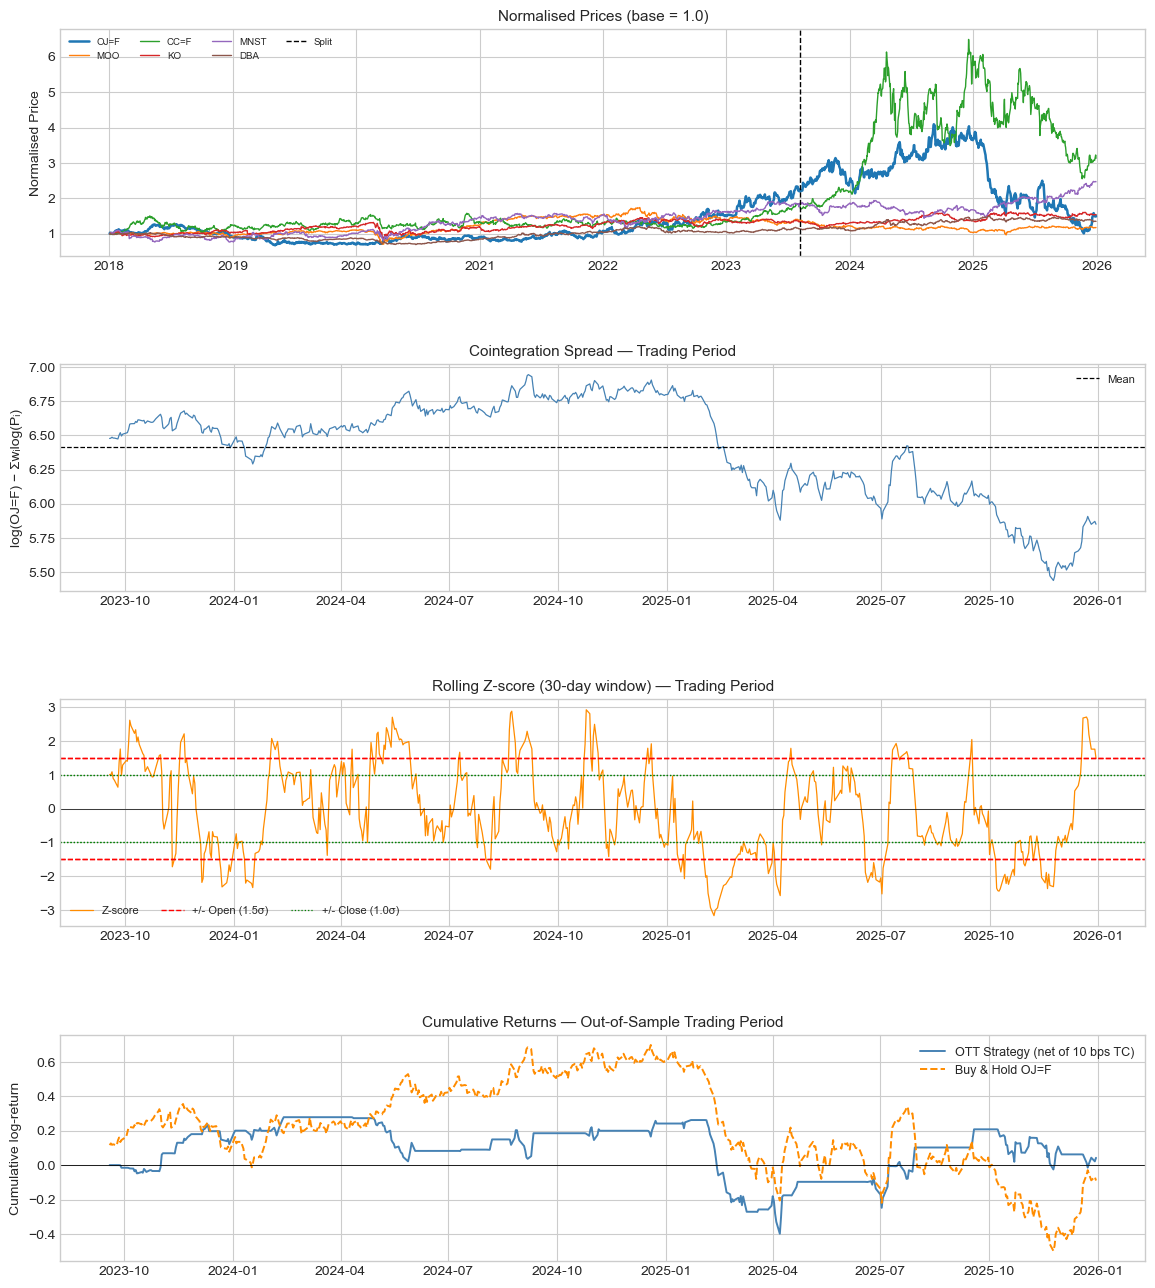

Saved: game1_results.png


In [ ]:
fig = plt.figure(figsize=(14, 16))
gs  = gridspec.GridSpec(4, 1, hspace=0.48)

# Normalised prices
ax1 = fig.add_subplot(gs[0])
for col in [ANCHOR_TICKER] + SELECTED_ASSETS:
    norm = df_prices[col] / df_prices[col].iloc[0]
    lw   = 1.8 if col == ANCHOR_TICKER else 1.0
    ax1.plot(df_prices.index, norm, label=col, linewidth=lw)
ax1.axvline(df_trading.index[0], color='k', ls='--', lw=1.0, label='Split')
ax1.set_title('Normalised Prices (base = 1.0)', fontsize=11)
ax1.legend(fontsize=7, ncol=4)
ax1.set_ylabel('Normalised Price')

# Spread
ax2 = fig.add_subplot(gs[1])
ax2.plot(df_signals_opt.index, df_signals_opt['Spread'],
         color='steelblue', lw=0.9)
ax2.axhline(df_signals_opt['Spread'].mean(),
            color='k', ls='--', lw=0.9, label='Mean')
ax2.set_title(f'Cointegration Spread — Trading Period', fontsize=11)
ax2.set_ylabel('log(OJ=F) − Σwᵢlog(Pᵢ)')
ax2.legend(fontsize=8)

# Z-score + thresholds
ax3 = fig.add_subplot(gs[2])
ax3.plot(df_signals_opt.index, df_signals_opt['Z_Score'],
         color='darkorange', lw=0.9, label='Z-score')
for sign, lbl in [(1, 'Open'), (-1, '')]:
    ax3.axhline( sign*OPT_O, color='red',   ls='--', lw=1.0,
                label=f'+/- Open ({OPT_O}σ)' if sign==1 else None)
    ax3.axhline(-sign*OPT_O, color='red',   ls='--', lw=1.0)
    ax3.axhline( sign*OPT_C, color='green', ls=':',  lw=0.9,
                label=f'+/- Close ({OPT_C}σ)' if sign==1 else None)
    ax3.axhline(-sign*OPT_C, color='green', ls=':',  lw=0.9)
ax3.axhline(0, color='k', lw=0.5)
ax3.set_title(f'Rolling Z-score ({OPT_W}-day window) — Trading Period', fontsize=11)
ax3.legend(fontsize=8, ncol=3)

# Equity curve
ax4 = fig.add_subplot(gs[3])
ott_cum = df_bt_opt['Cum_Return'].dropna()
bh_cum  = bh_returns.cumsum()
common  = ott_cum.index.intersection(bh_cum.index)
ax4.plot(common, ott_cum.loc[common], color='steelblue', lw=1.4,
         label='OTT Strategy (net of 10 bps TC)')
ax4.plot(common, bh_cum.loc[common],  color='darkorange', lw=1.4,
         ls='--', label='Buy & Hold OJ=F')
ax4.axhline(0, color='k', lw=0.6)
ax4.set_title('Cumulative Returns — Out-of-Sample Trading Period', fontsize=11)
ax4.set_ylabel('Cumulative log-return')
ax4.legend(fontsize=9)

plt.savefig('game1_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: game1_results.png')

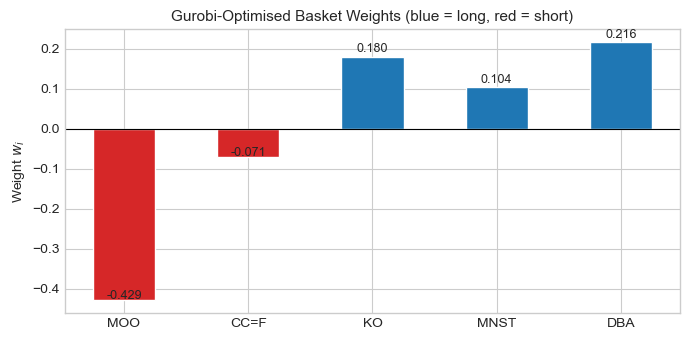

Beta check  : Σβᵢwᵢ = -1.73e-18  (≈ 0 ✓)
Dollar check: Σwᵢ   = 0.00e+00          (≈ 0 ✓)


In [ ]:
fig2, ax = plt.subplots(figsize=(7, 3.5))
colors = ['#1f77b4' if v > 0 else '#d62728' for v in optimized_weights.values]
bars   = ax.bar(optimized_weights.index, optimized_weights.values,
                color=colors, edgecolor='white', width=0.5)
ax.axhline(0, color='k', lw=0.8)
for bar, val in zip(bars, optimized_weights.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + 0.004 * np.sign(val), f'{val:.3f}',
            ha='center', va='bottom', fontsize=9)
ax.set_title('Gurobi-Optimised Basket Weights (blue = long, red = short)', fontsize=11)
ax.set_ylabel('Weight $w_i$')
plt.tight_layout()
plt.savefig('game1_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Beta check  : Σβᵢwᵢ = {(betas*optimized_weights).sum():.2e}  (≈ 0)')
print(f'Dollar check: Σwᵢ   = {optimized_weights.sum():.2e}          (≈ 0)')

In [36]:
print('═' * 55)
print('   TRADING GAME #1 — FINAL SUMMARY')
print('═' * 55)
print(f'  Anchor         : {ANCHOR_TICKER}')
print(f'  Basket         : {SELECTED_ASSETS}')
print(f'  Formation      : {df_formation.index[0].date()} → {df_formation.index[-1].date()}')
print(f'  Trading        : {df_trading.index[0].date()} → {df_trading.index[-1].date()}')
print(f'  Window         : {OPT_W} days   Open: {OPT_O}σ   Close: {OPT_C}σ')
print(f'  Trans. cost    : {TC*10000:.0f} bps per leg')
print('─' * 55)
print(f'  Ann. Return    OTT: {strat_opt["Annualized_Return"]:+.2%}  '
      f'  B&H: {bench_metrics["Annualized_Return"]:+.2%}')
print(f'  Sharpe Ratio   OTT: {strat_opt["Sharpe_Ratio"]:+.2f}       '
      f'  B&H: {bench_metrics["Sharpe_Ratio"]:+.2f}')
print(f'  Max Drawdown   OTT: {strat_opt["Max_Drawdown"]:.2%}       '
      f'  B&H: {bench_metrics["Max_Drawdown"]:.2%}')
print(f'  Calmar Ratio   OTT: {strat_opt["Calmar_Ratio"]:+.2f}       '
      f'  B&H: {bench_metrics["Calmar_Ratio"]:+.2f}')
print('═' * 55)

═══════════════════════════════════════════════════════
   TRADING GAME #1 — FINAL SUMMARY
═══════════════════════════════════════════════════════
  Anchor         : OJ=F
  Basket         : ['MOO', 'CC=F', 'KO', 'MNST', 'DBA']
  Formation      : 2018-01-02 → 2023-08-04
  Trading        : 2023-08-07 → 2025-12-30
  Window         : 30 days   Open: 1.5σ   Close: 1.0σ
  Trans. cost    : 10 bps per leg
───────────────────────────────────────────────────────
  Ann. Return    OTT: +1.86%    B&H: -3.75%
  Sharpe Ratio   OTT: -0.06         B&H: -0.15
  Max Drawdown   OTT: 51.83%         B&H: 75.36%
  Calmar Ratio   OTT: +0.04         B&H: -0.05
═══════════════════════════════════════════════════════
